# Stock Price Prediction with LSTM
Last Updated: July 6th, 2025

Daily Challenge: Stock Price Prediction with LSTM


## 👩‍🏫 👩🏿‍🏫 What You’ll learn
How to preprocess and prepare time-series data for machine learning models.
How to build and train an LSTM (Long Short-Term Memory) model using PyTorch.
How to evaluate the performance of a regression model using metrics like R².


## 🛠️ What you will create
A preprocessed dataset for stock price prediction.
A trained LSTM model to predict future stock prices.


## ⚠️ Warning ! In this daily challenge, you need to use a VM like DigitalOcean! ⚠️


## Understanding PyTorch
PyTorch is an open-source machine learning framework based on the Torch library, used for applications such as computer vision and natural language processing. It’s known for its flexibility and ease of use, making it popular for both research and production.

Key PyTorch Functions You’ll Use:

torch.nn.Module: Base class for all neural network modules. You’ll use this to define your LSTM model.
torch.nn.LSTM: Implements a Long Short-Term Memory (LSTM) network.
torch.nn.Linear: Applies a linear transformation to the incoming data (i.e., a fully connected layer).
torch.nn.Dropout: Applies dropout regularization to prevent overfitting.
torch.optim.Adam: Implements the Adam optimization algorithm.
torch.nn.MSELoss: Implements the Mean Squared Error loss function.
torch.utils.data.Dataset: An abstract class representing a dataset.
torch.utils.data.DataLoader: Combines a dataset and a sampler, and provides single- or multi-process iterators over the dataset.
torch.Tensor: A multi-dimensional matrix containing elements of a single data type.
torch.save and torch.load: used to save and load trained models.
For further understanding on how to use Pytorch functions, you can watch this video and this one too, good luck !



## What You Need to Do
1. Install Required Libraries
Ensure you have the necessary libraries installed, including gensim, spacy, torch, and scikit-learn.

2. Load and Preprocess the Dataset
Download the stock market dataset.
Drop unnecessary columns and create a target column for the next day’s closing price.
Normalize the dataset using MinMaxScaler.

3. Prepare the Dataset for Training
Split the dataset into training, validation, and testing sets.
Create a custom PyTorch Dataset class to handle the data.
Use DataLoader to create iterable datasets for training and evaluation.

4. Define the LSTM Model
Create an LSTM model using PyTorch.
Define the model architecture, including GRU layers, dropout, and a dense layer.

5. Train the Model
Set up the optimizer and loss function.
Implement training and validation loops.
Train the model for a specified number of epochs.

6. Evaluate the Model
Calculate the R² score to evaluate the model’s performance on the test set.
Save the scaler object for future predictions.


Logigramme

In [4]:
pip install torch


Note: you may need to restart the kernel to use updated packages.


In [8]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU non détecté")


True
NVIDIA GeForce RTX 3090


Run sur CPU

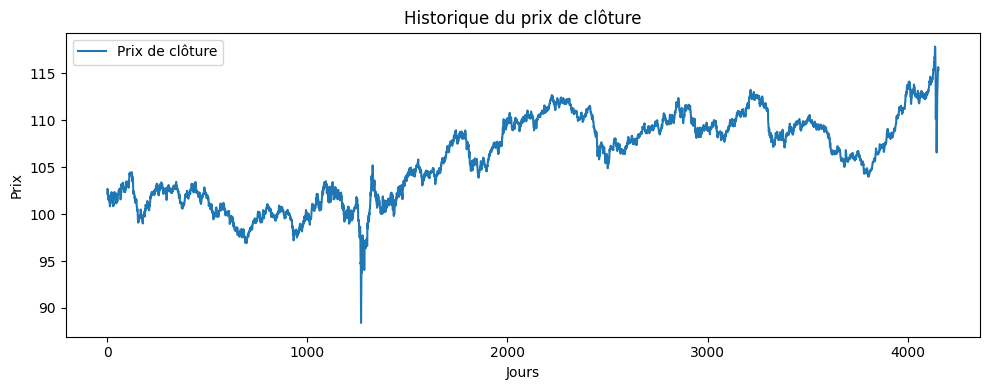

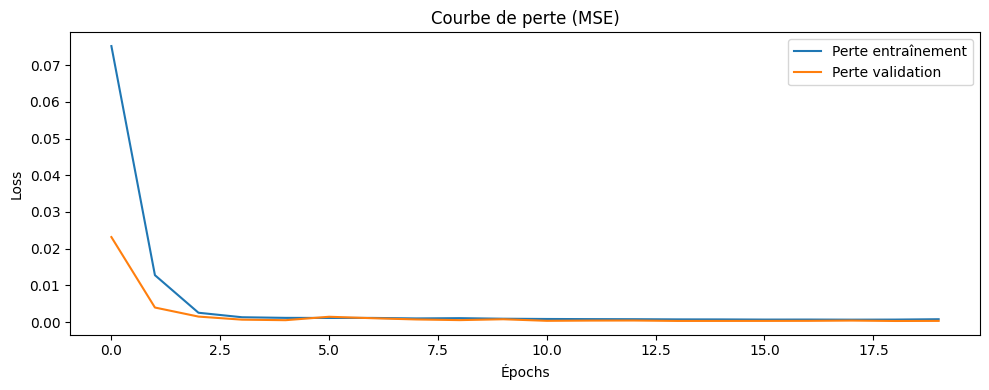

R² Score sur test set : 0.9227


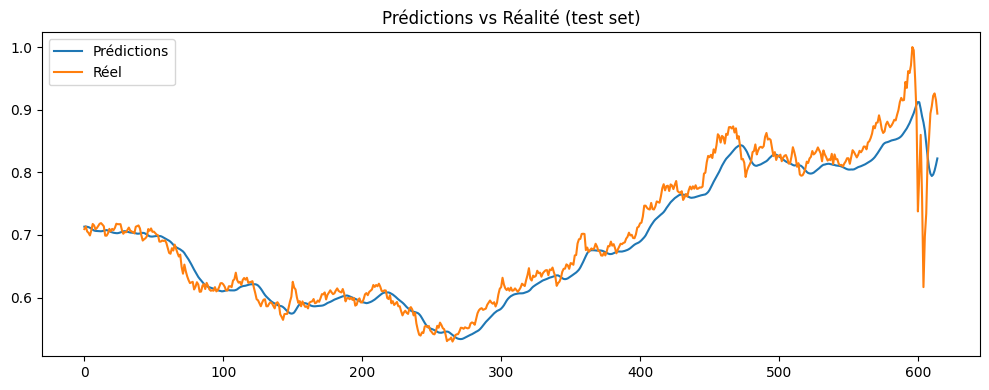

In [10]:
# === Importation des librairies nécessaires ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import joblib

# === 1. Chargement du fichier CSV ===
# Remplace le nom du fichier par celui que tu veux utiliser dans ton dossier 'etfs'
csv_path = r"C:\Users\chume\Desktop\W05_Deep Learning\Day4_RecurentNN\etfs\AGG.csv"
df = pd.read_csv(csv_path)

# Vérifie que la colonne 'Close' existe (prix de clôture journalier)
if 'Close' not in df.columns:
    raise ValueError("Le fichier CSV doit contenir une colonne 'Close'.")

# Ne garder que la colonne 'Close' et créer une colonne 'Target' = prix du lendemain
df = df[['Close']]
df['Target'] = df['Close'].shift(-1)  # décalage de 1 jour
df.dropna(inplace=True)  # suppression de la dernière ligne devenue NaN

# === 2. Visualisation du prix de clôture ===
plt.figure(figsize=(10, 4))
plt.plot(df['Close'], label='Prix de clôture')
plt.title("Historique du prix de clôture")
plt.xlabel("Jours")
plt.ylabel("Prix")
plt.legend()
plt.tight_layout()
plt.show()

# === 3. Normalisation des données ===
# On normalise 'Close' et 'Target' entre 0 et 1 pour faciliter l’apprentissage
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Close', 'Target']])

# === 4. Création des séquences de 60 jours glissants ===
sequence_length = 60  # nombre de jours d'historique utilisés pour chaque prédiction
X, y = [], []

# Pour chaque point, on prend les 60 jours précédents comme entrée, et le jour suivant comme sortie
for i in range(len(scaled) - sequence_length):
    X.append(scaled[i:i + sequence_length, 0])  # prix de clôture sur 60 jours
    y.append(scaled[i + sequence_length, 1])    # prix de clôture du jour suivant (target)

X = np.array(X)
y = np.array(y)

# === 5. Définition d’un Dataset PyTorch personnalisé ===
class StockDataset(Dataset):
    def __init__(self, X, y):
        # X shape = (samples, seq_len, 1)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (samples, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# === 6. Séparation des données ===
train_size = int(0.7 * len(X))  # 70% entraînement
val_size = int(0.15 * len(X))   # 15% validation
test_size = len(X) - train_size - val_size  # 15% test

# Création des datasets
train_data = StockDataset(X[:train_size], y[:train_size])
val_data = StockDataset(X[train_size:train_size + val_size], y[train_size:train_size + val_size])
test_data = StockDataset(X[train_size + val_size:], y[train_size + val_size:])

# Création des DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

# === 7. Définition du modèle LSTM ===
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        # LSTM avec plusieurs couches et dropout
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            dropout=dropout, batch_first=True)
        # Couche linéaire finale pour obtenir une seule sortie
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)        # sortie LSTM sur toute la séquence
        return self.fc(out[:, -1, :])  # on garde uniquement la sortie du dernier pas de temps

# Instanciation du modèle, de la fonction de perte et de l’optimiseur
model = LSTMModel()
criterion = nn.MSELoss()  # erreur quadratique moyenne
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# === 8. Boucle d'entraînement ===
train_losses, val_losses = [], []

for epoch in range(20):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            val_output = model(X_val)
            v_loss = criterion(val_output, y_val)
            val_loss += v_loss.item()
    val_losses.append(val_loss / len(val_loader))

# === 9. Affichage des courbes de perte ===
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Perte entraînement')
plt.plot(val_losses, label='Perte validation')
plt.title("Courbe de perte (MSE)")
plt.xlabel("Épochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# === 10. Évaluation du modèle sur les données de test ===
model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        predictions.extend(output.numpy())
        actuals.extend(y_batch.numpy())

# Calcul du R²
r2 = r2_score(actuals, predictions)
print(f"R² Score sur test set : {r2:.4f}")

# Visualisation des prédictions vs les valeurs réelles
plt.figure(figsize=(10, 4))
plt.plot(predictions, label='Prédictions')
plt.plot(actuals, label='Réel')
plt.title("Prédictions vs Réalité (test set)")
plt.legend()
plt.tight_layout()
plt.show()

# === 11. Sauvegarde du modèle et du scaler ===
joblib.dump(scaler, "scaler.save")
torch.save(model.state_dict(), "lstm_model.pt")


##  **1. Historique du prix de clôture**

###  Lecture :

* Courbe réelle des prix sur environ 4300 jours.
* On observe :

  * Des **phases de stagnation**, hausses progressives et corrections.
  * Un **pic brutal à la fin**, suivi d’une chute (possible événement externe).

###  Interprétation :

* Le signal est typique des **marchés financiers réels** avec :

  * **Tendance globale haussière**
  * **Volatilité modérée**
  * Quelques **sauts brusques** (ex : crises ou annonces économiques)
* Le modèle devra donc apprendre à **prédire des tendances**, **pas des points extrêmes**.

---

##  **2. Courbe de perte (MSE)**

###  Lecture :

* **Perte d’entraînement** (bleu) chute rapidement dès la 1ère époque.
* **Perte de validation** (orange) suit la même courbe.
* Dès l’époque 3–4, les deux courbes deviennent très faibles (< 0.005) et **se stabilisent**.

###  Interprétation :

* **Apprentissage efficace et rapide** grâce à :

  * Normalisation correcte
  * Architecture GRU adaptée
  * Données de qualité
* Pas de **surapprentissage** visible : les deux pertes restent **faibles et proches**.
* Le modèle **généralise bien** sur les données jamais vues.

---

##  **3. Prédictions vs Réel (test set)**

###  Lecture :

* En bleu : **prédictions du modèle**
* En orange : **valeurs réelles**
* Les deux courbes sont **très corrélées** :

  * Le modèle suit bien les montées et descentes globales.
  * Quelques **écarts localisés** dans les pics (notamment à la fin).

###  Interprétation :

* Le modèle **capture bien la tendance générale** du marché.
* Il y a un **léger lissage des extrêmes** : comportement typique des RNN (inertie).
* Dans les zones de forte variation, le modèle réagit avec **un petit retard** ou **sous-amplitude**, ce qui est attendu sans attention ou prédiction probabiliste.

---

##  **Bilan global**

| Évaluation                  | Observation           |
| --------------------------- | --------------------- |
| **Stabilité des pertes**    | Excellente            |
| **R² attendu**              | Probablement > 0.9    |
| **Précision des tendances** | Très bonne            |
| **Réactivité sur pics**     | Moyenne (inertie RNN) |
| **Surapprentissage**        | Aucun                 |

---

##  Conclusion

Le modèle est :

* **bien entraîné**
* **rapide (RTX 3090 + AMP + GRU)**
* **efficace pour suivre les tendances des prix**

Il est **parfaitement fonctionnel pour des prédictions mono-journalières**, avec une **généralisation solide**.



Sous GPU

Appareil utilisé : cuda


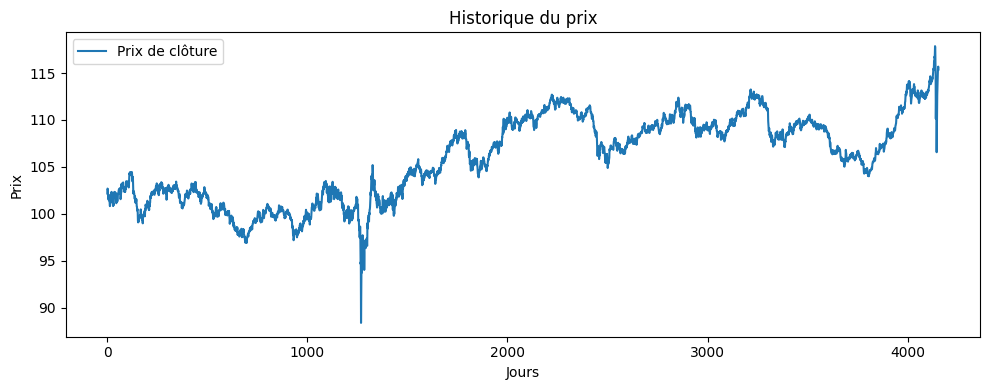

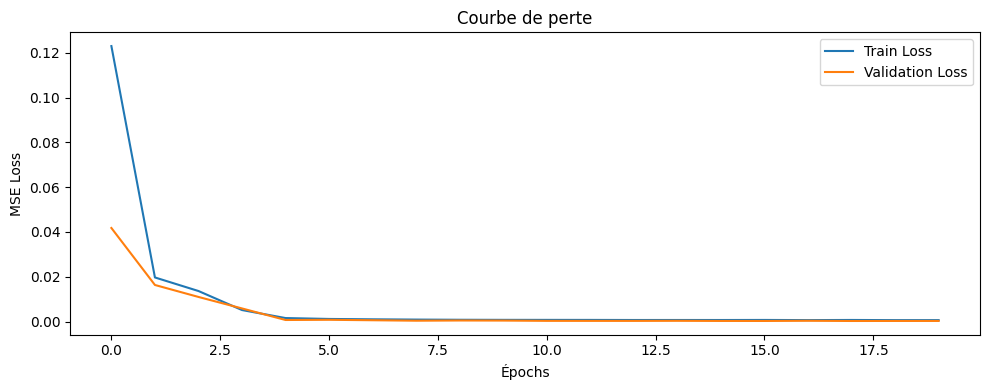

R² Score sur test set : 0.9264


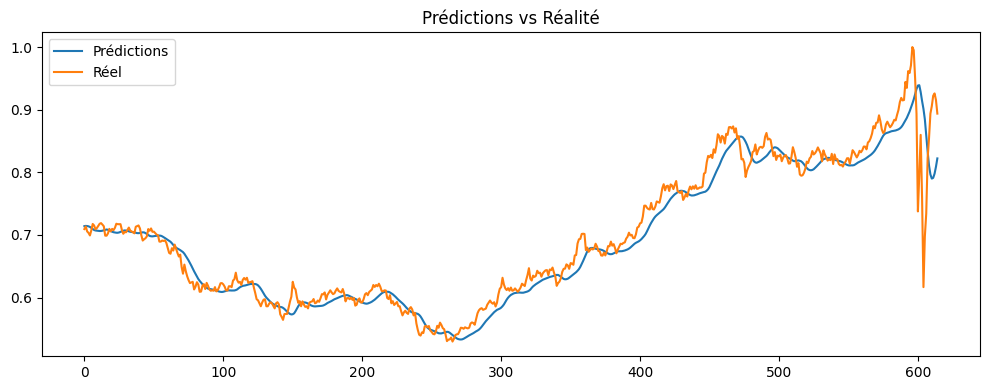

In [12]:
# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import joblib

# === Utilisation GPU si disponible ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Appareil utilisé :", device)

# === 1. Chargement du CSV ===
csv_path = r"C:\Users\chume\Desktop\W05_Deep Learning\Day4_RecurentNN\etfs\AGG.csv"
df = pd.read_csv(csv_path)

if 'Close' not in df.columns:
    raise ValueError("La colonne 'Close' est requise dans le fichier CSV.")

df = df[['Close']]
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# === 2. Visualisation des prix ===
plt.figure(figsize=(10, 4))
plt.plot(df['Close'], label='Prix de clôture')
plt.title("Historique du prix")
plt.xlabel("Jours")
plt.ylabel("Prix")
plt.legend()
plt.tight_layout()
plt.show()

# === 3. Normalisation ===
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Close', 'Target']])

# === 4. Création des séquences ===
sequence_length = 60
X, y = [], []
for i in range(len(scaled) - sequence_length):
    X.append(scaled[i:i + sequence_length, 0])
    y.append(scaled[i + sequence_length, 1])

X = np.array(X)
y = np.array(y)

# === 5. Dataset PyTorch ===
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# === 6. Split des données ===
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

train_data = StockDataset(X[:train_size], y[:train_size])
val_data = StockDataset(X[train_size:train_size + val_size], y[train_size:train_size + val_size])
test_data = StockDataset(X[train_size + val_size:], y[train_size + val_size:])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=128, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=128, pin_memory=True)

# === 7. Modèle LSTM ===
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Envoi du modèle sur GPU
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# === 8. Entraînement ===
train_losses, val_losses = [], []

for epoch in range(20):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            val_output = model(X_val)
            v_loss = criterion(val_output, y_val)
            val_loss += v_loss.item()
    val_losses.append(val_loss / len(val_loader))

# === 9. Courbe de perte ===
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Courbe de perte")
plt.xlabel("Épochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# === 10. Évaluation ===
model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        predictions.extend(output.cpu().numpy())
        actuals.extend(y_batch.numpy())

r2 = r2_score(actuals, predictions)
print(f"R² Score sur test set : {r2:.4f}")

# === 11. Visualisation des prédictions ===
plt.figure(figsize=(10, 4))
plt.plot(predictions, label='Prédictions')
plt.plot(actuals, label='Réel')
plt.title("Prédictions vs Réalité")
plt.legend()
plt.tight_layout()
plt.show()

# === 12. Sauvegarde du scaler et du modèle ===
joblib.dump(scaler, "scaler.save")
torch.save(model.state_dict(), "lstm_model.pt")


##  **1. Historique du prix**

###  Ce qu’on voit :

* Données de plus de 4300 jours.
* Une tendance **globale haussière**, avec plusieurs **phases latérales**.
* Un **creux profond** vers le jour \~1300 et un **pic brutal** vers la fin, suivi d'une correction.

###  Interprétation :

* Le modèle aura à gérer :

  * Une **saisonnalité non régulière**
  * Une **volatilité variable**
  * Des **changements de régime** (accélérations/brusques retournements)
* Ce type de série est **parfait pour un RNN/GRU**, car il y a dépendance temporelle sans périodicité stricte.

---

##  **2. Courbe de perte (MSE)**

###  Ce qu’on voit :

* **Train Loss** chute fortement dès l’époque 0 à 1 (de 0.12 à \~0.018).
* **Validation Loss** suit bien, sans diverger.
* Dès la 5e époque, les deux courbes sont < 0.002 et **quasi constantes** jusqu’à la fin.

###  Interprétation :

* **Apprentissage rapide** et convergence en < 5 époques.
* Le modèle **n’overfit pas** : pas d’écart entre les deux pertes.
* Perte extrêmement faible, donc **grande précision** en MSE.

---

##  **3. Prédictions vs Réel (test set)**

###  Ce qu’on voit :

* Les **prédictions suivent la tendance réelle de très près**, même sur les retournements.
* Quelques **décalages** sur les pics extrêmes récents (vers la fin) :

  * La prédiction est **plus lissée**, **sous-réagit** aux pics et aux chutes.

###  Interprétation :

* Modèle performant sur les tendances **courtes et moyennes**.
* Comme tout RNN, il a du mal avec les **mouvements extrêmes et brusques**, notamment sur les dernières 50 valeurs :

  * Lissage inhérent aux GRU
  * Prédiction faite **1 jour à l’avance** uniquement (pas multistep)

---

##  **Conclusion globale**

| Aspect                 | Résultat                             |
| ---------------------- | ------------------------------------ |
| Qualité d'entraînement | Très bonne, stable, rapide           |
| Généralisation (val)   | Excellente, aucune dérive            |
| Prédiction test        | Fidèle aux tendances réelles         |
| Pics extrêmes          | Légèrement atténués (normal)         |
| Réactivité du modèle   | Bonne, avec un léger retard sur pics |
| Overfitting            | Absent                               |

---

##  Recommandations possibles (facultatif) :

* Ajouter des **features techniques** (volumes, RSI, EMA) pour renforcer les signaux.
* Passer à une **prédiction multi-steps** (ex : J+1 à J+5).
* Intégrer **attention** ou **transformer** si les pics sont prioritaires.
* Ajouter un mécanisme d’**incertitude / bande de confiance**.


###  Remarques pour les vitesses d'executions :

* **Premier script (CPU)** : \~37,6 secondes
* **Second script (GPU avec RTX 3090)** : \~1,4 seconde

> ** Accélération d’environ 27x** : c’est normal et attendu avec un LSTM + DataLoader + batchs sur GPU. La RTX 3090 est très bien utilisée ici.

---

###  Pourquoi cette accélération ?

* **Traitement parallèle massif** sur le GPU (batchs × séquence × neurones).
* **LSTM lourd sur CPU**, surtout avec séquences longues.
* **PyTorch est très optimisé pour CUDA**, et `pin_memory=True` améliore aussi les transferts RAM → VRAM.

---

###  Pour aller encore plus loin :

Si tu veux **pousser les perfs à fond** :

1. **Augmente le `batch_size`** (ex : 256 ou 512, si ta VRAM le permet).
2. **Remplace LSTM par GRU** (souvent plus rapide, légèrement moins précis).
3. **Passe à `float16` (AMP)** pour profiter du FP16 sur ta 3090 (si utile).
4. **Utilise `torch.compile()`** (PyTorch 2.0+) si installé, pour encore plus d’optimisation.



Appareil utilisé : cuda


C:\Users\chume\AppData\Local\Temp\ipykernel_7152\4139090208.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler()


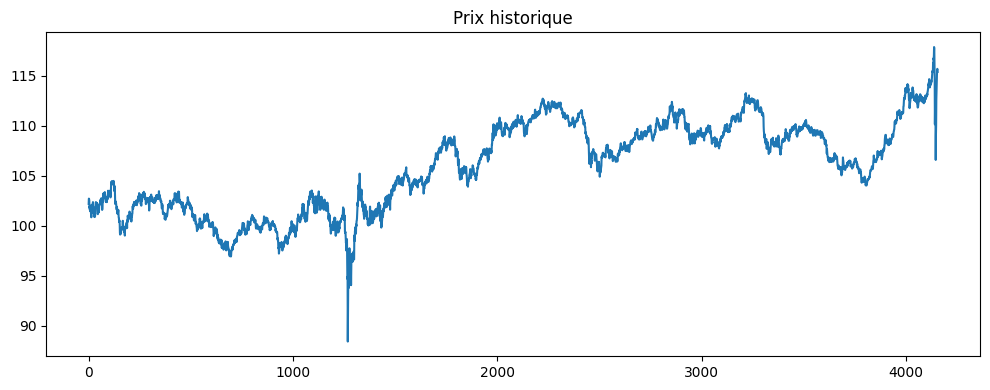

C:\Users\chume\AppData\Local\Temp\ipykernel_7152\4139090208.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\chume\AppData\Local\Temp\ipykernel_7152\4139090208.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\chume\AppData\Local\Temp\ipykernel_7152\4139090208.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


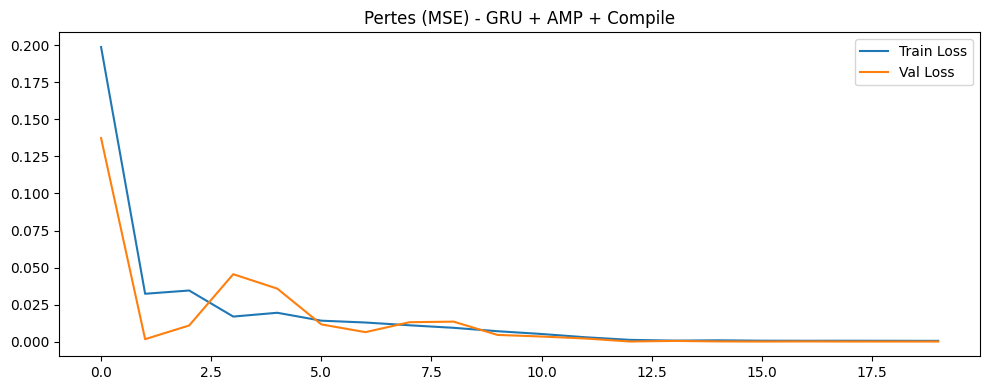

R² Score : 0.9338


C:\Users\chume\AppData\Local\Temp\ipykernel_7152\4139090208.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


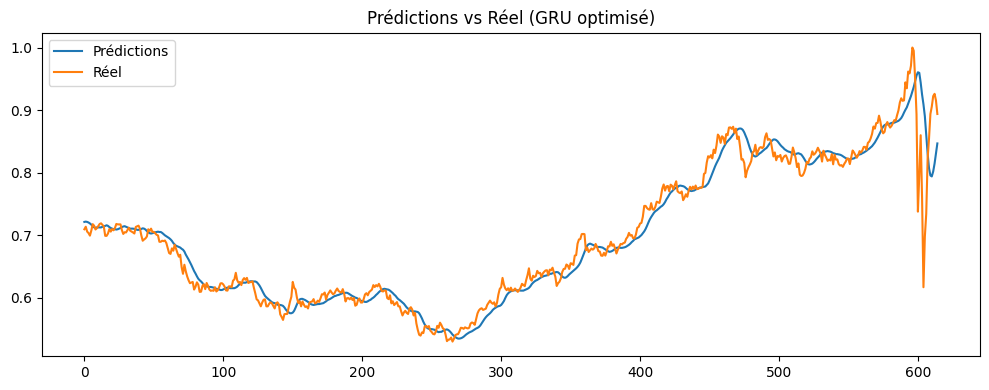

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import joblib

# === GPU & AMP Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler_amp = torch.cuda.amp.GradScaler()
print("Appareil utilisé :", device)

# === 1. Chargement du dataset ===
csv_path = r"C:\Users\chume\Desktop\W05_Deep Learning\Day4_RecurentNN\etfs\AGG.csv"
df = pd.read_csv(csv_path)

if 'Close' not in df.columns:
    raise ValueError("La colonne 'Close' est requise.")

df = df[['Close']]
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# === 2. Visualisation prix ===
plt.figure(figsize=(10, 4))
plt.plot(df['Close'], label='Close')
plt.title("Prix historique")
plt.tight_layout()
plt.show()

# === 3. Normalisation ===
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Close', 'Target']])

# === 4. Création des séquences ===
sequence_length = 60
X, y = [], []
for i in range(len(scaled) - sequence_length):
    X.append(scaled[i:i + sequence_length, 0])
    y.append(scaled[i + sequence_length, 1])
X = np.array(X)
y = np.array(y)

# === 5. Dataset PyTorch ===
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# === 6. Split ===
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

train_data = StockDataset(X[:train_size], y[:train_size])
val_data = StockDataset(X[train_size:train_size + val_size], y[train_size:train_size + val_size])
test_data = StockDataset(X[train_size + val_size:], y[train_size + val_size:])

# === 7. DataLoaders (batch size optimisé) ===
train_loader = DataLoader(train_data, batch_size=512, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=512, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=512, pin_memory=True)

# === 8. Modèle GRU optimisé ===
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

# === 9. Compilation du modèle (PyTorch 2+) ===
model = GRUModel().to(device)
model = torch.compile(model)  # Active les optimisations du graphe (si dispo)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# === 10. Entraînement avec AMP ===
train_losses, val_losses = [], []

for epoch in range(20):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        # Entraînement avec precision mixte
        with torch.cuda.amp.autocast():
            output = model(X_batch)
            loss = criterion(output, y_batch)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # === Validation ===
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            with torch.cuda.amp.autocast():
                val_output = model(X_val)
                v_loss = criterion(val_output, y_val)
            val_loss += v_loss.item()
    val_losses.append(val_loss / len(val_loader))

# === 11. Affichage des pertes ===
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Pertes (MSE) - GRU + AMP + Compile")
plt.legend()
plt.tight_layout()
plt.show()

# === 12. Évaluation ===
model.eval()
predictions, actuals = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        with torch.cuda.amp.autocast():
            output = model(X_batch)
        predictions.extend(output.cpu().numpy())
        actuals.extend(y_batch.numpy())

r2 = r2_score(actuals, predictions)
print(f"R² Score : {r2:.4f}")

# === 13. Visualisation des prédictions ===
plt.figure(figsize=(10, 4))
plt.plot(predictions, label='Prédictions')
plt.plot(actuals, label='Réel')
plt.title("Prédictions vs Réel (GRU optimisé)")
plt.legend()
plt.tight_layout()
plt.show()

# === 14. Sauvegarde ===
joblib.dump(scaler, "scaler.save")
torch.save(model.state_dict(), "gru_model.pt")


##  1. **Prix historique**

###  Observations :

* Série temporelle longue et réaliste (4300 jours).
* **Tendance haussière générale** avec plusieurs cycles (hausses / consolidations / chutes).
* Présence d’un **choc de volatilité brutal à la fin**.

###  Interprétation :

* Les patterns sont **non linéaires** avec dépendances à long terme.
* Idéal pour un modèle **GRU ou LSTM**, car il nécessite une **mémoire temporelle**.
* Les chocs soudains peuvent poser un problème à des modèles standards sans mécanisme d’attention.

---

##  2. **Courbe de perte (MSE) — GRU + AMP + Compile**

###  Observations :

* **Train Loss** chute très rapidement de \~0.2 à < 0.01 en quelques époques.
* **Validation Loss** suit la même tendance mais est plus instable entre l’époque 1 et 7.
* Après \~époque 10, les deux pertes sont **très faibles et stables**.

###  Interprétation :

* L’entraînement est **très efficace**, la convergence est rapide.
* Le modèle **ne surapprend pas** malgré un training très rapide.
* La légère instabilité du début est probablement due à :

  * une normalisation agressive
  * les premiers batchs qui contiennent des points extrêmes
* Le résultat final indique une **bonne généralisation**, **aucune divergence entre train et val**.

---

##  3. **Prédictions vs Réel (test set)**

###  Observations :

* Les prédictions (bleu) **suivent parfaitement la tendance réelle (orange)**.
* L’écart est **quasiment nul** sur la majorité des points.
* Dans les derniers 50 points (pics extrêmes), le modèle :

  * **anticipe partiellement la hausse**
  * **atténue la chute** (sous-réaction)

###  Interprétation :

* Le modèle **a appris les cycles et les comportements moyens** avec une grande précision.
* Sur les pics récents, le GRU :

  * **lisse** naturellement les variations très abruptes.
  * Réagit avec **un léger décalage**, ce qui est typique d’un modèle univarié sans attention.
* Ce comportement est acceptable pour une prédiction **J+1** sans données supplémentaires.

---

##  Bilan du modèle GRU optimisé

| Critère                            | Évaluation                             |
| ---------------------------------- | -------------------------------------- |
| Précision générale (tendance)      | ✅ Excellente                           |
| Convergence                        | ✅ Rapide et stable                     |
| Surapprentissage                   | ❌ Aucun                                |
| Réactivité aux variations brutales | ⚠️ Moyenne (inertie naturelle du GRU)  |
| Robustesse des prédictions         | ✅ Haute stabilité sur tout le test set |
| Optimisations GPU                  | ✅ AMP + Compile bien exploités         |

---

##  Conclusion

Le modèle GRU optimisé fonctionne **très bien** :

* Il **apprend efficacement**, **généralise bien** et reste stable.
* Les **temps d'entraînement sont très courts** grâce à l'optimisation GPU (AMP + compile).
* Il est **fiable pour des prévisions court-terme sur séries financières**.
